In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process.kernels import (
    WhiteKernel, ConstantKernel, RBF, RationalQuadratic, ExpSineSquared, DotProduct
)
from statsmodels.tsa.stattools import adfuller
from tqdm import tqdm

from src.feature_manager_sim import FeatureManagerSim
from src.feature_manager import FeatureManager
from src.kernel_ridge_models import KernelRidgeEnsemble
from src.walk_forward import WalkForwardValidator
# import time
import time

ImportError: attempted relative import with no known parent package

In [2]:
# get the target, actual, and feature columns
feature_manager = FeatureManagerSim(features_config_path='../data/features_selected4.yaml')
feature_manager2 = FeatureManager(features_config_path='../data/features_selected3.yaml')
independent_variables = feature_manager2.get_features_for_time_pred(time_prediction='seven-day-ahead')
dependent_variables = feature_manager.get_dependent_variables(time_prediction='seven-day-ahead')
actuals_variables = feature_manager.get_actual_variables()

# print the outputs
print(f"Independent variables: {independent_variables}")
dependent_variable_new = [f"{x}_future_val" for x in dependent_variables]
print(f"Dependent variables: {dependent_variable_new}")
print(f"Actual variables: {actuals_variables}")

INFO:src.feature_manager_sim:Loaded features for 6 future time predictions
INFO:src.feature_manager_sim:Available time predictions: ['current_values', 'thirty-day-ahead', 'sixty-day-ahead', 'seven-day-ahead', 'one-day-ahead', 'future_values']
INFO:src.feature_manager:Loaded features for 5 future time predictions
INFO:src.feature_manager:Available time predictions: ['dependent_variables', 'thirty-day-ahead', 'sixty-day-ahead', 'seven-day-ahead', 'one-day-ahead']
INFO:src.feature_manager:Retrieved 18 features for seven-day-ahead
INFO:src.feature_manager_sim:Retrieved 11 dependent variables for seven-day-ahead
INFO:src.feature_manager_sim:Retrieved 11 actual variables


Independent variables: ['U6RATE', 'MEDCPIM157SFRBCLE_moving_avg_60', 'STICKCPIM158SFRBATL_moving_avg_60', 'DGS5', 'DGS7', 'DGS10', 'DGS3', 'DGS3MO', 'DGS1', 'DGS30', 'REAINTRATREARAT1YE_moving_avg_60', 'DGS6MO', 'REAINTRATREARAT1YE_exp_moving_avg_60', 'MEDCPIM157SFRBCLE_exp_moving_avg_60', 'U6RATE_exp_moving_avg_60', 'DGS20', 'DGS1MO', 'DGS2']
Dependent variables: ['DGS1MO_future_val', 'DGS3MO_future_val', 'DGS6MO_future_val', 'DGS1_future_val', 'DGS2_future_val', 'DGS3_future_val', 'DGS5_future_val', 'DGS7_future_val', 'DGS10_future_val', 'DGS20_future_val', 'DGS30_future_val']
Actual variables: ['DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', 'DGS7', 'DGS10', 'DGS20', 'DGS30']


# KRR Simulation Test

- Test the sampling method on different time periods using the analysis df

In [3]:
raw_data = pd.read_parquet('../data/kernel_regression_train_shifted_7_.parquet')
train_df = raw_data[(raw_data.index.to_timestamp() < pd.to_datetime('2018-01-01')) & (raw_data.index.to_timestamp() >= pd.to_datetime('2011-01-01'))]

analysis_df = train_df.iloc[:1500]
validation_df = train_df.iloc[1500:]
# get the min and max index values
print(f"Training Min index value: {analysis_df.index.min()}")
print(f"Training Max index value: {analysis_df.index.max()}")
print("\n")
print(f"Validation Min index value: {validation_df.index.min()}")
print(f"Validation Max index value: {validation_df.index.max()}")
# check if all columns are present
full_columns = set(independent_variables).union(set(dependent_variables)).union(set(actuals_variables).union(set(dependent_variable_new)))
set(full_columns) - set(analysis_df.columns.tolist())

Training Min index value: 2011-01-01
Training Max index value: 2015-02-08


Validation Min index value: 2015-02-09
Validation Max index value: 2017-12-31


set()

In [4]:
# create the kernel ridge ensemble
krr_ensemble = KernelRidgeEnsemble(training_metric='r2_flat', random_state=42)
# scale the data
scalerx = StandardScaler()
saclery = StandardScaler()

analysis_df_xscaled = scalerx.fit_transform(analysis_df[independent_variables])
analysis_df_yscaled = saclery.fit_transform(analysis_df[dependent_variable_new])

print(type(analysis_df_yscaled))
print(type(analysis_df_xscaled))

INFO:src.kernel_ridge_models:Created 5 kernel configurations
INFO:src.kernel_ridge_models:Initialized KRR ensemble with 5 kernels, metric=r2_flat, random_state=42


<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [5]:
# create a dataframe
analysis_df_xscaled = pd.DataFrame(analysis_df_xscaled, columns=independent_variables, index=analysis_df.index)
analysis_df_yscaled = pd.DataFrame(analysis_df_yscaled, columns=dependent_variable_new, index=analysis_df.index)

analysis_df_yscaled.head()

,DGS1MO_future_val,DGS3MO_future_val,DGS6MO_future_val,DGS1_future_val,DGS2_future_val,DGS3_future_val,DGS5_future_val,DGS7_future_val,DGS10_future_val,DGS20_future_val,DGS30_future_val
period,,,,,,,,,,,
2011-01-01,2.211764,2.394967,2.173556,2.822342,1.523017,1.320378,1.485019,1.670034,1.856155,2.064627,2.030673
2011-01-02,2.211764,2.394967,2.173556,2.822342,1.523017,1.320378,1.485019,1.670034,1.856155,2.064627,2.030673
2011-01-03,2.469806,2.678015,2.173556,2.822342,1.454441,1.213753,1.420185,1.594457,1.818712,2.030086,2.012390
2011-01-04,2.727848,2.678015,2.426216,2.616692,1.523017,1.355920,1.528241,1.688928,1.912318,2.081897,2.048956
2011-01-05,2.727848,2.678015,2.173556,2.205392,1.591592,1.355920,1.549853,1.707822,1.968481,2.116438,2.103804


In [6]:
# transform the validation set
validation_df_xscaled = scalerx.transform(validation_df[independent_variables])
# validation_df_yscaled = saclery.transform(validation_df[dependent_variable_new])
# transform to a dataframe
validation_df_xscaled = pd.DataFrame(validation_df_xscaled, columns=independent_variables, index=validation_df.index)
# validation_df_yscaled = pd.DataFrame(validation_df_yscaled, columns=dependent_variable_new, index=validation_df.index)
# train the krr model
krr_ensemble.train_historical(x=analysis_df_xscaled, y=analysis_df_yscaled)
print("model trained")

INFO:src.kernel_ridge_models:Training KRR with 5 kernels and 4 alpha values


Fitting 2 folds for each of 20 candidates, totalling 40 fits


INFO:src.kernel_ridge_models:Training completed. Best alpha: 1.0, Best kernel: 1**2 * ExpSineSquared(length_scale=2, periodicity=...


model trained


Prediction point: 2015-02-15: 0.02
Prediction point: 2015-05-16: 0.01
Prediction point: 2015-07-17: 0.04
Prediction point: 2015-12-18: 0.15
Prediction point: 2016-02-19: 0.26
Prediction point: 2016-03-20: 0.24


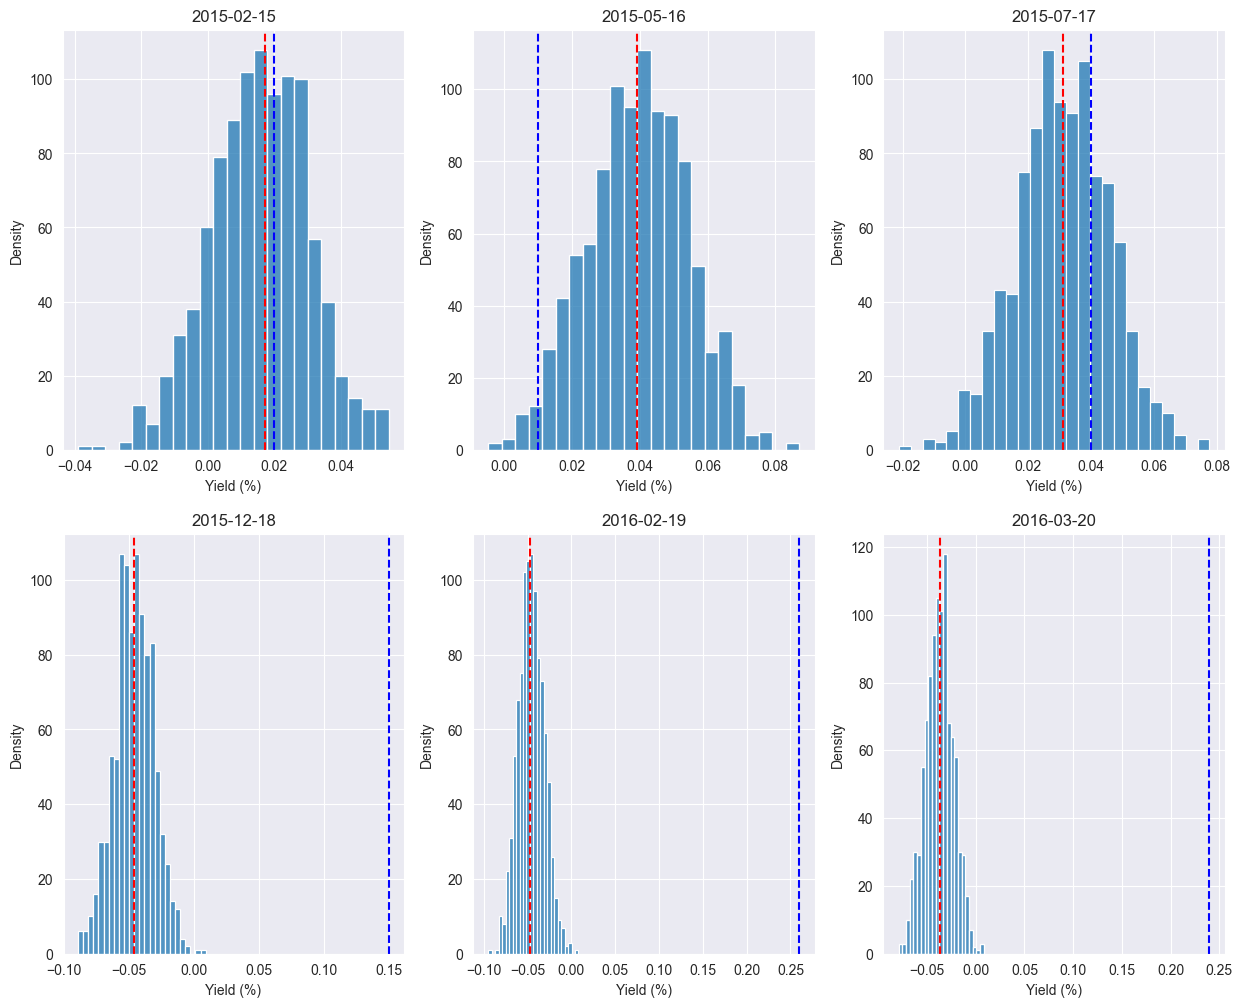

In [9]:
# predict 6 points using the sampling method in the validation set and plot
# get 6 index points from the validation set
prediction_point_list = ['2015-02-15', '2015-05-16', '2015-07-17', '2015-12-18', '2016-02-19', '2016-03-20']

fig, axes = plt.subplots(2, 3, figsize=(15, 12))
dgs_value = 'DGS1MO_future_val'
axes = axes.flatten()
for i, prediction_point in enumerate(prediction_point_list):
    validation_df_xscaled_point = validation_df_xscaled.loc[prediction_point].to_frame().T
    validation_df_y_actual = validation_df[dgs_value].loc[prediction_point]
    print(f"Prediction point: {prediction_point}: {validation_df_y_actual}")
    mean_prediction = krr_ensemble.predict_val(x=validation_df_xscaled_point)
    # create a one row dataframe with the prediction point
    mean_prediction_df = pd.DataFrame(data=mean_prediction, columns=dependent_variable_new)
    mean_prediction_df[dependent_variable_new] = saclery.inverse_transform(mean_prediction_df[dependent_variable_new])
    # print(mean_prediction_df)
    samples_df = krr_ensemble.predict_val_distribution(x=validation_df_xscaled_point, y_columns=dependent_variable_new)
    # inverse transform the samples
    samples_df[dependent_variable_new] = saclery.inverse_transform(samples_df[dependent_variable_new])
    # # plot the distribution
    sns.histplot(samples_df[dgs_value], ax=axes[i])
    axes[i].axvline(mean_prediction_df[dgs_value].values[0], color='red', linestyle='dashed')
    axes[i].axvline(validation_df_y_actual, color='blue', linestyle='dashed')
    axes[i].set_title(prediction_point)
    axes[i].set_xlabel('Yield (%)')
    axes[i].set_ylabel('Density')

In [10]:
# test_df = pd.DataFrame(
#     {'x': [1, 2, 3, 4, 5, 6, 7, 8, -9, -10],
#      'y': [1, 2, 3, 4, 5, 6, 7, 8, -9, -10],
#      'z': [11, 12, 13, 14, 15, 16, 17, 18, 19, 20]}
# )

residual_means = [
                            [
                        float((np.abs(krr_ensemble.residuals[col_i]).mean() + np.abs(krr_ensemble.residuals[col_j]).mean())) / 2 for col_j in range(krr_ensemble.residuals.shape[1])
                        ]
                        for col_i in range(krr_ensemble.residuals.shape[1])
                    ]

# test_df_mean_matrix = [
#     [float((test_df[col_i].mean() + test_df[col_j].mean())) / 2 for col_j in test_df.columns]
#     for col_i in test_df.columns
# ]
residual_means

# test_df.cov().to_numpy()
# test_df_mean = test_df.mean()
# print(test_df_mean)
# test_df_mean_matrix = test_df_mean.values.reshape(-1, 1)
# print(test_df_mean_matrix)
test_df_mean_matrix_df = pd.DataFrame(data=residual_means, columns=dependent_variable_new, index=dependent_variable_new)
test_df_mean_matrix_df
# test_df_mean_matrix

,DGS1MO_future_val,DGS3MO_future_val,DGS6MO_future_val,DGS1_future_val,DGS2_future_val,DGS3_future_val,DGS5_future_val,DGS7_future_val,DGS10_future_val,DGS20_future_val,DGS30_future_val
DGS1MO_future_val,0.434008,0.411056,0.367122,0.372403,0.399985,0.323486,0.283573,0.275625,0.273531,0.269535,0.322200
DGS3MO_future_val,0.411056,0.388104,0.344170,0.349451,0.377033,0.300534,0.260621,0.252673,0.250579,0.246584,0.299248
DGS6MO_future_val,0.367122,0.344170,0.300236,0.305517,0.333099,0.256600,0.216687,0.208739,0.206645,0.202649,0.255314
DGS1_future_val,0.372403,0.349451,0.305517,0.310798,0.338380,0.261881,0.221968,0.214020,0.211926,0.207931,0.260595
DGS2_future_val,0.399985,0.377033,0.333099,0.338380,0.365962,0.289463,0.249550,0.241602,0.239508,0.235512,0.288177
DGS3_future_val,0.323486,0.300534,0.256600,0.261881,0.289463,0.212964,0.173051,0.165103,0.163009,0.159013,0.211678
DGS5_future_val,0.283573,0.260621,0.216687,0.221968,0.249550,0.173051,0.133138,0.125190,0.123096,0.119101,0.171765
DGS7_future_val,0.275625,0.252673,0.208739,0.214020,0.241602,0.165103,0.125190,0.117242,0.115148,0.111152,0.163817
DGS10_future_val,0.273531,0.250579,0.206645,0.211926,0.239508,0.163009,0.123096,0.115148,0.113054,0.109058,0.161723
DGS20_future_val,0.269535,0.246584,0.202649,0.207931,0.235512,0.159013,0.119101,0.111152,0.109058,0.105063,0.157728


In [8]:
mean_prediction

array([[-0.70241232, -1.12069965, -0.57679067,  1.02316731,  1.09531232,
         0.75105107,  0.26437351, -0.03692389, -0.44735615, -0.71023526,
        -0.79262913]])

In [14]:
krr_ensemble.residuals

array([[ 0.6295891 ,  0.61748241,  0.54972174, ...,  0.33397933,
         0.38096241,  0.35302917],
       [ 0.61053248,  0.58535165,  0.51187953, ...,  0.28090103,
         0.32917089,  0.30219082],
       [ 0.43923639,  0.48058654,  0.37059577, ...,  0.22898299,
         0.27798799,  0.26183013],
       ...,
       [ 0.1268206 , -0.12870966, -0.08092304, ...,  0.05219977,
        -0.04506881, -0.08805878],
       [ 0.12389543, -0.13315616, -0.07557284, ...,  0.03184454,
        -0.08288103, -0.13285153],
       [ 0.12022361, -0.13861731, -0.07063739, ...,  0.01067063,
        -0.12210203, -0.17940223]], shape=(1500, 11))